<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/Lab2_MangNeural_SauRieng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI THỰC HÀNH SỐ 2 – MẠNG NEURAL NHIỀU ĐẦU RA VÀ LAN TRUYỀN NGƯỢC
## Phân loại sầu riêng xuất khẩu

**Sinh viên:** BÙI VĂN HUÂN &nbsp;&nbsp; **MSSV:** 26110028 &nbsp;&nbsp;


## Bước 0. Kết nối Google Drive và nạp thư viện

In [1]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/ANN_Lab'
except ImportError:
    DATA_DIR = './ANN_Lab'
os.makedirs(DATA_DIR, exist_ok=True)
print('Thư mục dữ liệu:', DATA_DIR, '|', os.listdir(DATA_DIR))

Mounted at /content/drive
Thư mục dữ liệu: /content/drive/MyDrive/ANN_Lab | ['lab2_train.csv', 'lab1_duyet_vay.csv', 'lab2_sau_rieng.csv', 'lab2_test.csv', 'lab1_train.csv', 'lab1_test.csv']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

## Bước 1. Đọc dữ liệu

In [3]:
FILE_ALL = os.path.join(DATA_DIR, 'lab2_sau_rieng.csv')
def make_lab2(seed=2026, n=400):
    rng = np.random.default_rng(seed)
    kl = np.clip(rng.normal(3.5, 1.2, n), 1.0, 6.8).round(2)
    brix = np.clip(rng.normal(30, 4, n), 20, 42).round(1)
    com = np.clip(rng.normal(27, 5, n), 12, 42).round(1)
    vo = np.clip(rng.normal(9, 2, n), 4, 15).round(1)
    ngay = rng.integers(1, 11, n)
    band = 1/(1+np.exp(-4*(kl-2.5))) * 1/(1+np.exp(4*(kl-5.0)))
    s = (4*band + 0.30*(brix-30) + 0.18*(com-27) - 0.2*(vo-9)
         - 0.15*(ngay-5.5) + rng.normal(0, 0.4, n))
    return pd.DataFrame({'ma_trai': [f'SR{i:03d}' for i in range(1, n+1)], 'khoi_luong': kl,
                         'do_brix': brix, 'ty_le_com': com, 'do_day_vo': vo,
                         'so_ngay_thu_hoach': ngay,
                         'phan_loai': np.where(s > 2.0, 'XuatKhau', 'NoiDia')})
if not os.path.exists(FILE_ALL):
    make_lab2().to_csv(FILE_ALL, index=False)
    print('Đã sinh dữ liệu và lưu vào', FILE_ALL)
df = pd.read_csv(FILE_ALL)
print('Kích thước:', df.shape)
df.head(10)

Kích thước: (400, 7)


,ma_trai,khoi_luong,do_brix,ty_le_com,do_day_vo,so_ngay_thu_hoach,phan_loai
0,SR001,2.55,23.9,31.9,14.0,6,NoiDia
1,SR002,3.79,25.6,27.3,9.7,5,XuatKhau
2,SR003,1.22,30.5,26.2,10.2,7,NoiDia
3,SR004,5.17,32.5,30.0,8.7,10,NoiDia
4,SR005,4.27,36.6,30.3,12.2,4,XuatKhau
5,SR006,3.15,31.5,23.2,8.6,1,XuatKhau
6,SR007,3.13,31.9,23.8,9.9,9,XuatKhau
7,SR008,3.86,36.8,30.6,6.8,10,XuatKhau
8,SR009,3.18,26.9,29.6,4.0,10,XuatKhau
9,SR010,3.23,26.2,26.0,13.4,7,NoiDia


## Bước 2. Khám phá dữ liệu

In [4]:
FEATURES = ['khoi_luong', 'do_brix', 'ty_le_com', 'do_day_vo', 'so_ngay_thu_hoach']
print(df['phan_loai'].value_counts())
df.groupby('phan_loai')[FEATURES].mean()

phan_loai
XuatKhau    256
NoiDia      144
Name: count, dtype: int64


,khoi_luong,do_brix,ty_le_com,do_day_vo,so_ngay_thu_hoach
phan_loai,,,,,
NoiDia,3.4653,28.1542,24.6431,9.1458,5.7014
XuatKhau,3.6188,31.2734,27.7043,8.6750,5.1797


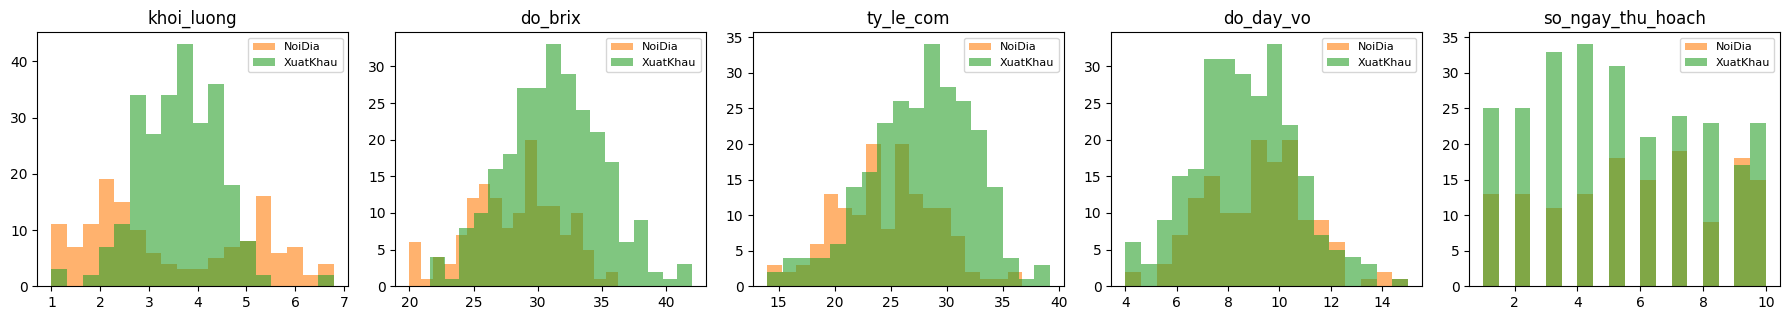

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.3))
for ax, col in zip(axes, FEATURES):
    for lab, color in [('NoiDia', 'tab:orange'), ('XuatKhau', 'tab:green')]:
        ax.hist(df.loc[df.phan_loai == lab, col], bins=18, alpha=0.6, color=color, label=lab)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

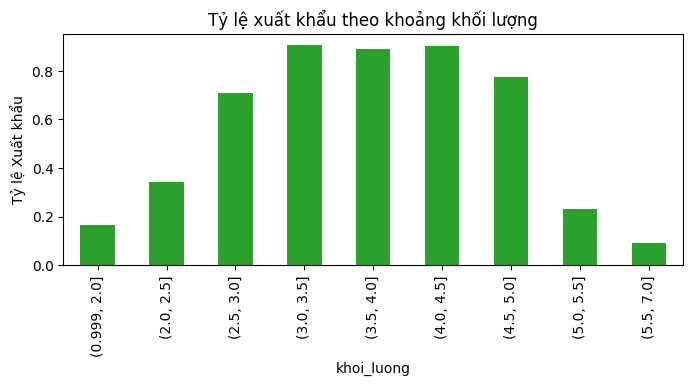

khoi_luong
(0.999, 2.0]    0.17
(2.0, 2.5]      0.34
(2.5, 3.0]      0.71
(3.0, 3.5]      0.91
(3.5, 4.0]      0.89
(4.0, 4.5]      0.90
(4.5, 5.0]      0.77
(5.0, 5.5]      0.23
(5.5, 7.0]      0.09
Name: phan_loai, dtype: float64
Độ lệch chuẩn khối lượng theo lớp: {'NoiDia': 1.69, 'XuatKhau': 0.84}


In [6]:
bins = pd.cut(df['khoi_luong'], bins=[1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 7], include_lowest=True)
is_xk = (df['phan_loai'] == 'XuatKhau')
rate = is_xk.groupby(bins, observed=True).mean()
rate.plot(kind='bar', color='tab:green', figsize=(8, 3))
plt.ylabel('Tỷ lệ Xuất khẩu')
plt.title('Tỷ lệ xuất khẩu theo khoảng khối lượng')
plt.show()
print(rate.round(2))
print('Độ lệch chuẩn khối lượng theo lớp:', df.groupby('phan_loai')['khoi_luong'].std().round(2).to_dict())

### Trả lời Câu hỏi 1
- **Tỷ lệ xuất khẩu theo khối lượng:** khoảng 0.17 với trái 1 – 2 kg, 0.34 với 2 – 2.5 kg, tăng lên 0.7 – 0.9 trong khoảng 2.5 – 5 kg, rồi giảm mạnh còn 0.23 (5 – 5.5 kg) và 0.09 (> 5.5 kg). Đây là quan hệ **"tăng rồi giảm" (không đơn điệu)**.
- **Vì sao trung bình khối lượng hai lớp gần nhau (3.62 và 3.47 kg)?** Nhóm Nội địa gồm **cả trái quá nhỏ lẫn trái quá to**; hai phía bù trừ nhau nên trung bình rơi vào giữa, gần với trung bình nhóm Xuất khẩu. Dấu hiệu nhận ra: độ lệch chuẩn khối lượng của nhóm Nội địa (1.69) gấp đôi nhóm Xuất khẩu (0.84). Trung bình và tương quan tuyến tính (+0.06) có thể che giấu một thuộc tính rất quan trọng ⇒ luôn cần vẽ biểu đồ.
- **Mạng một lớp có mô tả được không?** **Không.** Mỗi đầu ra $O = \text{sigmoid}(\mathbf{w}\cdot\mathbf{x} - b)$ là hàm **đơn điệu** theo từng đầu vào (luôn tăng nếu $w > 0$, luôn giảm nếu $w < 0$), nên không thể vừa tăng vừa giảm theo khối lượng.

## Bước 3. Mã hóa nhãn thành 2 đầu ra và chia 80/20

In [7]:
df['T1_XuatKhau'] = (df['phan_loai'] == 'XuatKhau').astype(int)
df['T2_NoiDia'] = 1 - df['T1_XuatKhau']
TARGETS = ['T1_XuatKhau', 'T2_NoiDia']
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['phan_loai'])
train_df.to_csv(os.path.join(DATA_DIR, 'lab2_train.csv'), index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'lab2_test.csv'), index=False)
print(f'Train: {len(train_df)} trái, trong đó {train_df.T1_XuatKhau.sum()} XK')
print(f'Test:  {len(test_df)} trái, trong đó {test_df.T1_XuatKhau.sum()} XK')

Train: 320 trái, trong đó 205 XK
Test:  80 trái, trong đó 51 XK


## Bước 4. Chuẩn hóa theo tỷ lệ % của giá trị Max

In [8]:
X_max = train_df[FEATURES].max()
X_train = (train_df[FEATURES] / X_max).values
X_test = (test_df[FEATURES] / X_max).values
T_train = train_df[TARGETS].values
T_test = test_df[TARGETS].values
y_train = T_train[:, 0]
y_test = T_test[:, 0]
print('X_max =', X_max.to_dict())
pd.DataFrame(X_train[:6], columns=FEATURES).join(pd.DataFrame(T_train[:6], columns=TARGETS))

X_max = {'khoi_luong': 6.8, 'do_brix': 42.0, 'ty_le_com': 39.2, 'do_day_vo': 15.0, 'so_ngay_thu_hoach': 10.0}


,khoi_luong,do_brix,ty_le_com,do_day_vo,so_ngay_thu_hoach,T1_XuatKhau,T2_NoiDia
0,0.7574,0.7429,0.7781,0.5400,0.4,1,0
1,0.3206,0.7762,0.6199,0.7533,0.5,0,1
2,0.4735,0.8071,0.8087,0.5067,0.3,1,0
3,0.4000,0.9262,0.9107,0.4333,0.3,1,0
4,0.2235,0.7048,0.9362,0.5267,0.7,0,1
5,0.7838,0.5643,0.7781,0.8333,0.3,0,1


## Bước 5. Xây dựng mạng một lớp, 2 nút đầu ra (slide 36, 37)

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def forward_1layer(X, W, b):
    S = X @ W - b
    return S, sigmoid(S)
rng = np.random.default_rng(7)
W = rng.uniform(0, 1, size=(5, 2)).round(2)
b = rng.uniform(0, 1, size=2).round(2)
print(pd.DataFrame(W, index=FEATURES, columns=['-> Y1 (XK)', '-> Y2 (ND)']))
print('b =', b)
S, O = forward_1layer(X_train, W, b)
V = np.argmax(O, axis=1)
bang = pd.DataFrame(X_train[:10], columns=FEATURES)
bang['Net(XK)'] = O[:10, 0]
bang['Net(ND)'] = O[:10, 1]
bang['V(XK)'] = (V[:10] == 0).astype(int)
bang['V(ND)'] = (V[:10] == 1).astype(int)
bang['T(XK)'] = T_train[:10, 0]
bang['T(ND)'] = T_train[:10, 1]
display(bang)
err0 = np.mean(V != np.argmax(T_train, axis=1))
print(f'Tỷ lệ dự đoán sai ban đầu trên tập train: {err0:.1%}')

                   -> Y1 (XK)  -> Y2 (ND)
khoi_luong               0.63        0.90
do_brix                  0.78        0.23
ty_le_com                0.30        0.87
do_day_vo                0.01        0.82
so_ngay_thu_hoach        0.80        0.47
b = [0.3  0.28]


,khoi_luong,do_brix,ty_le_com,do_day_vo,so_ngay_thu_hoach,Net(XK),Net(ND),V(XK),V(ND),T(XK),T(ND)
0,0.7574,0.7429,0.7781,0.5400,0.4,0.7884,0.8676,0,1,1,0
1,0.3206,0.7762,0.6199,0.7533,0.5,0.7504,0.8291,0,1,0,1
2,0.4735,0.8071,0.8087,0.5067,0.3,0.7532,0.8309,0,1,1,0
3,0.4000,0.9262,0.9107,0.4333,0.3,0.7671,0.8294,0,1,1,0
4,0.2235,0.7048,0.9362,0.5267,0.7,0.7750,0.8401,0,1,0,1
5,0.7838,0.5643,0.7781,0.8333,0.3,0.7532,0.8866,0,1,0,1
6,0.5426,0.7214,0.7296,0.6800,0.1,0.7131,0.8339,0,1,1,0
7,0.6868,0.7500,0.6684,0.5933,0.7,0.8152,0.8707,0,1,1,0
8,0.4632,0.7500,0.5918,0.5733,0.1,0.6985,0.7927,0,1,1,0
9,0.6794,0.7071,0.6505,0.5133,0.8,0.8205,0.8649,0,1,1,0


Tỷ lệ dự đoán sai ban đầu trên tập train: 64.1%


In [10]:
# Bổ sung cho Câu hỏi 2
diff = O[:, 1] - O[:, 0]
print('Tổng trọng số cột Y1 =', W[:, 0].sum().round(2), '| cột Y2 =', W[:, 1].sum().round(2))
print('Net(ND) - Net(XK): min = %.3f | trung bình = %.3f | max = %.3f' % (diff.min(), diff.mean(), diff.max()))
print('Số mẫu được đoán Xuất khẩu:', int((V == 0).sum()))

Tổng trọng số cột Y1 = 2.52 | cột Y2 = 3.29
Net(ND) - Net(XK): min = 0.006 | trung bình = 0.070 | max = 0.154
Số mẫu được đoán Xuất khẩu: 0


### Trả lời Câu hỏi 2
- Hai giá trị **chênh lệch rất ít** (thường dưới 0.1) và **đều lớn** (Net(XK) ≈ 0.70 – 0.82, Net(ND) ≈ 0.79 – 0.89).
- **Vì sao?** Trọng số khởi tạo đều dương (trong [0, 1]) và đầu vào đã chuẩn hóa cũng dương, nên $S$ lớn, sigmoid gần vùng bão hòa phía trên. Cột trọng số nối vào $Y_2$ có tổng lớn hơn cột $Y_1$ (xem ô bổ sung), nên Net(ND) gần như luôn lớn hơn Net(XK) với mọi mẫu.
- **Ảnh hưởng:** mạng đoán **toàn bộ là Nội địa** ⇒ sai 64.1% = 205/320 (đúng bằng tỷ lệ lớp Xuất khẩu), tệ hơn cả mô hình "luôn đoán Xuất khẩu". Tương tự slide 39 (sai 42%), mạng chưa huấn luyện chỉ cho kết quả ngẫu nhiên hoặc thiên về một lớp tùy trọng số khởi tạo; cần huấn luyện để điều chỉnh trọng số.

## Bước 6. Tính tay một lần cập nhật trọng số cho mẫu đầu tiên (slide 40)

### Phần tính tay
Mẫu train đầu tiên là **SR352**: khoi_luong = 5.15, do_brix = 31.2, ty_le_com = 30.5, do_day_vo = 8.1, so_ngay = 4, nhãn **Xuất khẩu ⇒ T = (1, 0)**. η = 0.2.

**1. Chuẩn hóa** (Max = 6.8; 42; 39.2; 15; 10):
$$\mathbf{x} = \left(\tfrac{5.15}{6.8};\ \tfrac{31.2}{42};\ \tfrac{30.5}{39.2};\ \tfrac{8.1}{15};\ \tfrac{4}{10}\right) = (0.7574;\ 0.7429;\ 0.7781;\ 0.5400;\ 0.4000)$$

**2. Trọng số khởi tạo** (Bước 5, seed 7):

| | → Y₁ (XK) | → Y₂ (ND) |
|---|---|---|
| khoi_luong | 0.63 | 0.90 |
| do_brix | 0.78 | 0.23 |
| ty_le_com | 0.30 | 0.87 |
| do_day_vo | 0.01 | 0.82 |
| so_ngay_thu_hoach | 0.80 | 0.47 |
| bias b | 0.30 | 0.28 |

**3. Lan truyền thẳng** $S_j = \sum_i w_{ij}x_i + (-1)\,b_j$:
$$S_1 = 0.63(0.7574) + 0.78(0.7429) + 0.30(0.7781) + 0.01(0.54) + 0.80(0.4) - 0.30$$
$$= 0.4772 + 0.5794 + 0.2334 + 0.0054 + 0.3200 - 0.30 = 1.3154$$
$$S_2 = 0.90(0.7574) + 0.23(0.7429) + 0.87(0.7781) + 0.82(0.54) + 0.47(0.4) - 0.28$$
$$= 0.6816 + 0.1709 + 0.6769 + 0.4428 + 0.1880 - 0.28 = 1.8802$$
$$O_1 = \frac{1}{1 + e^{-1.3154}} = 0.7884, \qquad O_2 = \frac{1}{1 + e^{-1.8802}} = 0.8676$$
$O_2 > O_1$ ⇒ mạng đoán Nội địa (sai).

**4. Sai số:** $T_1 - O_1 = 1 - 0.7884 = 0.2116$; $\quad T_2 - O_2 = 0 - 0.8676 = -0.8676$.

**5. Cập nhật** $\Delta w_{ij} = \eta\, x_i (T_j - O_j)$, với $\eta(T_1 - O_1) = 0.04232$ và $\eta(T_2 - O_2) = -0.17352$:

| | $x_i$ | $\Delta w_{i1}$ | $\Delta w_{i2}$ | $w_{i1}$ mới | $w_{i2}$ mới |
|---|---|---|---|---|---|
| khoi_luong | 0.7574 | 0.2 × 0.7574 × 0.2116 = **0.0320** | 0.2 × 0.7574 × (−0.8676) = **−0.1314** | 0.6620 | 0.7686 |
| do_brix | 0.7429 | **0.0314** | **−0.1289** | 0.8114 | 0.1011 |
| ty_le_com | 0.7781 | **0.0329** | 0.2 × 0.7781 × (−0.8676) = **−0.1350** | 0.3329 | 0.7350 |
| do_day_vo | 0.5400 | **0.0229** | **−0.0937** | 0.0329 | 0.7263 |
| so_ngay_thu_hoach | 0.4000 | **0.0169** | **−0.0694** | 0.8169 | 0.4006 |

**Bias:** $\Delta b_j = \eta\,(-1)(T_j - O_j)$ ⇒ $\Delta b = (-0.0423;\ 0.1735)$ ⇒ $b$ mới $= (0.2577;\ 0.4535)$.

Ô lệnh dưới đây kiểm tra lại các con số trên.

In [11]:
eta = 0.2
x0 = X_train[0]
t0 = T_train[0]
o0 = forward_1layer(x0[None, :], W, b)[1][0]
print('x =', x0.round(4))
print('T =', t0, '| O =', o0.round(4), '| T - O =', (t0 - o0).round(4))
dW = eta * np.outer(x0, t0 - o0)
db = eta * (-1) * (t0 - o0)
print(pd.DataFrame(dW, index=FEATURES, columns=['ΔY1', 'ΔY2']).round(4))
print('Δb =', db.round(4))
print('S =', forward_1layer(x0[None, :], W, b)[0][0].round(4))
print('W mới:'); print(pd.DataFrame(W + dW, index=FEATURES, columns=['Y1', 'Y2']).round(4))
print('b mới =', (b + db).round(4))

x = [0.7574 0.7429 0.7781 0.54   0.4   ]
T = [1 0] | O = [0.7884 0.8676] | T - O = [ 0.2116 -0.8676]
                      ΔY1     ΔY2
khoi_luong         0.0320 -0.1314
do_brix            0.0314 -0.1289
ty_le_com          0.0329 -0.1350
do_day_vo          0.0229 -0.0937
so_ngay_thu_hoach  0.0169 -0.0694
Δb = [-0.0423  0.1735]
S = [1.3154 1.8802]
W mới:
                       Y1      Y2
khoi_luong         0.6620  0.7686
do_brix            0.8114  0.1011
ty_le_com          0.3329  0.7350
do_day_vo          0.0329  0.7263
so_ngay_thu_hoach  0.8169  0.4006
b mới = [0.2577 0.4535]


### Trả lời Câu hỏi 3
- Kết quả tính tay ở trên **khớp** với kết quả của ô lệnh (sai khác chỉ ở chữ số làm tròn thứ 4).
- **Vì sao mọi trọng số nối vào $Y_1$ thay đổi cùng chiều, còn $Y_2$ ngược chiều?** Trong một cột $j$, mọi $\Delta w_{ij} = \eta\, x_i (T_j - O_j)$ có chung thừa số $(T_j - O_j)$, còn $x_i \ge 0$, nên cả cột thay đổi **cùng dấu với $(T_j - O_j)$**. Mẫu đầu tiên là Xuất khẩu: $T_1 = 1 > O_1 = 0.79$ ⇒ cột $Y_1$ **tăng** (đẩy $O_1$ lên); $T_2 = 0 < O_2 = 0.87$ ⇒ cột $Y_2$ **giảm** (kéo $O_2$ xuống). Bias thay đổi ngược dấu vì đầu vào của nó là −1.
- **Vì sao độ lớn khác nhau trong cùng một cột?** $|\Delta w_{ij}|$ tỉ lệ với $x_i$: đầu vào nào lớn hơn thì "chịu trách nhiệm" nhiều hơn về sai số nên được điều chỉnh nhiều hơn (slide 29); ví dụ `ty_le_com` (0.778) thay đổi nhiều hơn `khoi_luong` (0.757), còn `so_ngay_thu_hoach` (0.4) thay đổi ít nhất. Ngoài ra sai số của $Y_2$ lớn hơn (0.87 so với 0.21) nên cột $Y_2$ thay đổi mạnh hơn khoảng 4 lần.

## Bước 7. Huấn luyện mạng một lớp qua 300 epoch

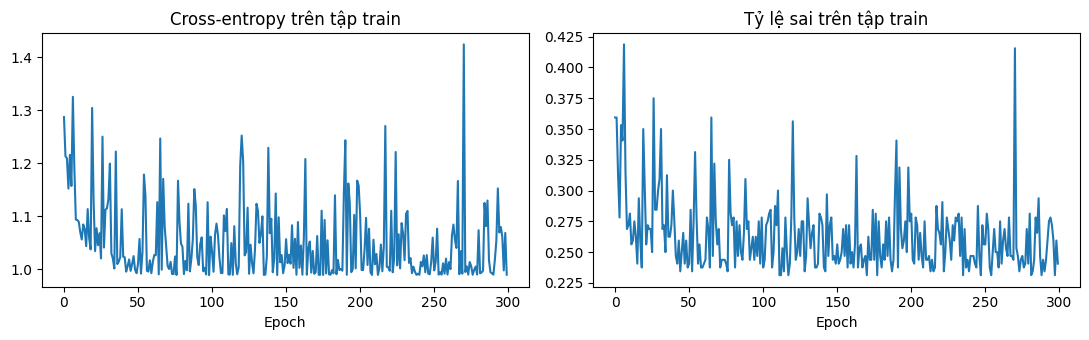

                   Y1 (XK)  Y2 (ND)
khoi_luong           0.733   -0.733
do_brix             13.476  -13.476
ty_le_com            9.311   -9.311
do_day_vo           -1.547    1.547
so_ngay_thu_hoach   -0.663    0.663
b = [ 14.249 -14.249]


In [12]:
def cross_entropy(T, O):
    O = np.clip(O, 1e-9, 1 - 1e-9)
    return -np.mean(np.sum(T*np.log(O) + (1-T)*np.log(1-O), axis=1))
def train_1layer(X, T, W, b, eta=0.2, epochs=300, seed=0):
    rng = np.random.default_rng(seed)
    W, b = W.copy(), b.copy()
    hist = []
    for ep in range(epochs):
        for i in rng.permutation(len(X)):
            o = forward_1layer(X[i:i+1], W, b)[1][0]
            e = T[i] - o
            W += eta * np.outer(X[i], e)
            b += eta * (-1) * e
        O_all = forward_1layer(X, W, b)[1]
        err = np.mean(np.argmax(O_all, 1) != np.argmax(T, 1))
        hist.append((cross_entropy(T, O_all), err))
    return W, b, np.array(hist)
W1, b1, hist1 = train_1layer(X_train, T_train, W, b, eta=0.2, epochs=300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist1[:, 0])
ax[0].set_title('Cross-entropy trên tập train')
ax[0].set_xlabel('Epoch')
ax[1].plot(hist1[:, 1])
ax[1].set_title('Tỷ lệ sai trên tập train')
ax[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()
print(pd.DataFrame(W1, index=FEATURES, columns=['Y1 (XK)', 'Y2 (ND)']).round(3))
print('b =', b1.round(3))

In [13]:
baseline = max(y_test.mean(), 1 - y_test.mean())
O_test1 = forward_1layer(X_test, W1, b1)[1]
pred1 = (np.argmax(O_test1, 1) == 0).astype(int)
acc1 = accuracy_score(y_test, pred1)
print(f'Mô hình cơ sở: {baseline:.3f} | Mạng MỘT lớp: {acc1:.3f}')
print(classification_report(y_test, pred1, target_names=['Nội địa', 'Xuất khẩu']))

Mô hình cơ sở: 0.637 | Mạng MỘT lớp: 0.762
              precision    recall  f1-score   support

     Nội địa       0.69      0.62      0.65        29
   Xuất khẩu       0.80      0.84      0.82        51

    accuracy                           0.76        80
   macro avg       0.74      0.73      0.74        80
weighted avg       0.76      0.76      0.76        80



### Trả lời Câu hỏi 4
- Trọng số `khoi_luong` nối vào $Y_1$ **dương nhưng rất nhỏ** (≈ 0.73, so với 13.5 của Brix và 9.3 của tỷ lệ cơm). Nghĩa là mạng **gần như bỏ qua khối lượng**, và còn "cho rằng" trái càng to càng dễ xuất khẩu.
- Điều này **không phản ánh đúng** tiêu chí "chỉ nhận trái 2.5 – 5 kg": trái 1.5 kg và 6.2 kg đều không đạt, nhưng mạng một lớp không phân biệt được.
- **Nguyên nhân:** mỗi đầu ra là sigmoid của một tổ hợp tuyến tính, nên theo từng đầu vào nó chỉ có thể tăng đều hoặc giảm đều. Không có trọng số đơn lẻ nào biểu diễn được "khoảng 2.5 – 5 kg"; vì hai phía (quá nhỏ, quá to) bù trừ nhau, cách tốt nhất mà mạng tìm được là đặt trọng số khối lượng gần 0. Hệ quả: **recall lớp Nội địa thấp (0.62)** – các trái Nội địa do sai khối lượng bị đoán nhầm thành Xuất khẩu; độ chính xác test chỉ 0.762.

### Trả lời Câu hỏi 5
- Cột $Y_2$ **đúng bằng cột $Y_1$ đổi dấu**, và $b_2 = -b_1$ (14.249 và −14.249).
- **Giải thích:** hai nút ra được huấn luyện **độc lập** (luật cập nhật của nút $j$ chỉ dùng $T_j - O_j$) với hai đích bù nhau $T_2 = 1 - T_1$. Vì $\text{sigmoid}(-S) = 1 - \text{sigmoid}(S)$, nếu $(\mathbf{w}, b)$ tối ưu cho bài toán "có phải Xuất khẩu?" thì $(-\mathbf{w}, -b)$ tối ưu cho bài toán "có phải Nội địa?". Sau đủ nhiều epoch (với cùng thứ tự duyệt mẫu), ảnh hưởng của khác biệt khi khởi tạo bị xóa và hai cột hội tụ về hai nghiệm đối nhau.
- Hệ quả: với bài toán hai lớp, **nút thứ hai là dư thừa**, một nút sigmoid là đủ (như sklearn ở Bước 10). Với nhiều lớp, người ta dùng hàm **softmax** để các đầu ra có tổng bằng 1.

## Bước 8. Mạng nhiều lớp 5-8-2 và lan truyền ngược

Học: 256 | Kiểm định: 64 | Test: 80
Epoch có lỗi kiểm định nhỏ nhất: 663


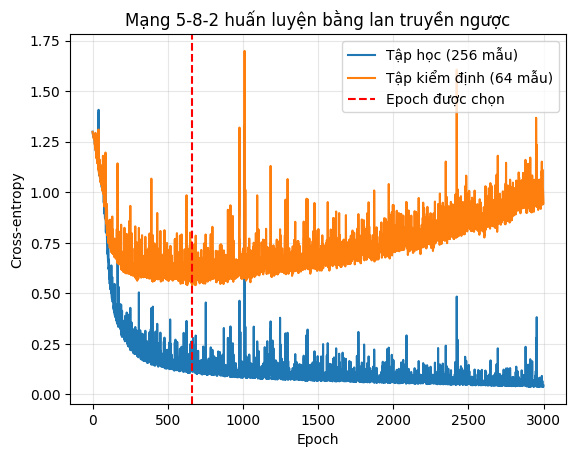

Cross-entropy tại epoch được chọn: học = 0.113, kiểm định = 0.537
Cross-entropy ở epoch cuối:        học = 0.044, kiểm định = 0.945


In [14]:
X_sub, X_val, T_sub, T_val = train_test_split(X_train, T_train, test_size=0.2, random_state=42, stratify=y_train)
print('Học:', len(X_sub), '| Kiểm định:', len(X_val), '| Test:', len(X_test))
class MLP:
    def __init__(self, n_in, n_hidden, n_out, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 1, (n_in, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, 1, (n_hidden, n_out))
        self.b2 = np.zeros(n_out)
    def forward(self, X):
        self.h = sigmoid(X @ self.W1 - self.b1)
        self.O = sigmoid(self.h @ self.W2 - self.b2)
        return self.O
    def backward(self, X, T, eta):
        n = len(X)
        d2 = T - self.O
        d1 = (d2 @ self.W2.T) * self.h * (1 - self.h)
        self.W2 += eta * self.h.T @ d2 / n
        self.b2 += eta * (-1) * d2.mean(axis=0)
        self.W1 += eta * X.T @ d1 / n
        self.b1 += eta * (-1) * d1.mean(axis=0)
    def fit(self, X, T, X_val, T_val, eta=0.5, epochs=3000, batch=16, seed=0):
        rng = np.random.default_rng(seed)
        self.hist = []
        best = np.inf
        for ep in range(epochs):
            idx = rng.permutation(len(X))
            for s in range(0, len(X), batch):
                bi = idx[s:s + batch]
                self.forward(X[bi])
                self.backward(X[bi], T[bi], eta)
            loss_tr = cross_entropy(T, self.forward(X))
            loss_va = cross_entropy(T_val, self.forward(X_val))
            self.hist.append((loss_tr, loss_va))
            if loss_va < best:
                best = loss_va
                self.best_epoch = ep + 1
                self.best = [p.copy() for p in (self.W1, self.b1, self.W2, self.b2)]
        self.W1, self.b1, self.W2, self.b2 = self.best
        return self
    def predict(self, X):
        return (np.argmax(self.forward(X), axis=1) == 0).astype(int)
mlp = MLP(n_in=5, n_hidden=8, n_out=2, seed=1)
mlp.fit(X_sub, T_sub, X_val, T_val, eta=0.5, epochs=3000, batch=16)
print('Epoch có lỗi kiểm định nhỏ nhất:', mlp.best_epoch)
h = np.array(mlp.hist)
plt.plot(h[:, 0], label='Tập học (256 mẫu)')
plt.plot(h[:, 1], label='Tập kiểm định (64 mẫu)')
plt.axvline(mlp.best_epoch, color='r', ls='--', label='Epoch được chọn')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.title('Mạng 5-8-2 huấn luyện bằng lan truyền ngược')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f'Cross-entropy tại epoch được chọn: học = {h[mlp.best_epoch-1, 0]:.3f}, kiểm định = {h[mlp.best_epoch-1, 1]:.3f}')
print(f'Cross-entropy ở epoch cuối:        học = {h[-1, 0]:.3f}, kiểm định = {h[-1, 1]:.3f}')

Mô hình cơ sở: 0.637 | Một lớp: 0.762 | Nhiều lớp 5-8-2: 0.938
              precision    recall  f1-score   support

     Nội địa       0.90      0.93      0.92        29
   Xuất khẩu       0.96      0.94      0.95        51

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



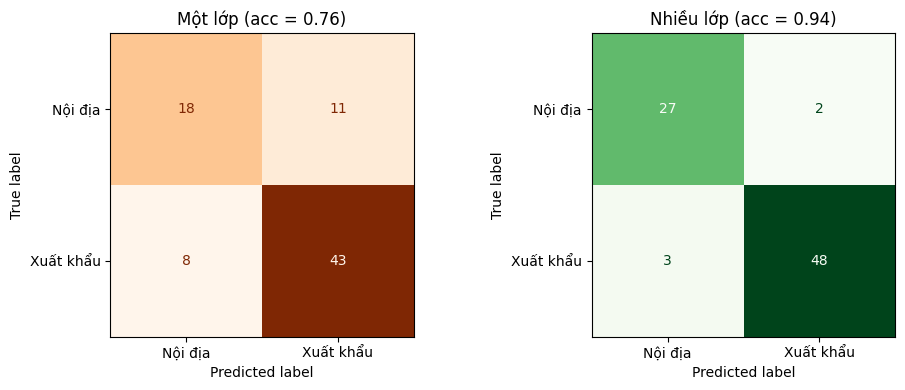

In [15]:
pred2 = mlp.predict(X_test)
acc2 = accuracy_score(y_test, pred2)
print(f'Mô hình cơ sở: {baseline:.3f} | Một lớp: {acc1:.3f} | Nhiều lớp 5-8-2: {acc2:.3f}')
print(classification_report(y_test, pred2, target_names=['Nội địa', 'Xuất khẩu']))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Nội địa', 'Xuất khẩu']
ConfusionMatrixDisplay(confusion_matrix(y_test, pred1), display_labels=labels).plot(ax=ax[0], cmap='Oranges', colorbar=False)
ax[0].set_title(f'Một lớp (acc = {acc1:.2f})')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred2), display_labels=labels).plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title(f'Nhiều lớp (acc = {acc2:.2f})')
plt.tight_layout()
plt.show()

### Trả lời Câu hỏi 6
- Trong khoảng vài trăm epoch đầu, cả hai đường cùng giảm. Sau khoảng **epoch 663** (epoch được chọn, cross-entropy kiểm định ≈ 0.55), lỗi trên tập học **tiếp tục giảm** (về ≈ 0.05) nhưng lỗi trên tập kiểm định **lại tăng dần** (lên ≈ 1.0).
- Hiện tượng này gọi là **quá khớp (overfitting)**: mạng bắt đầu "học thuộc" cả nhiễu của 256 mẫu học thay vì quy luật chung, nên kém đi trên dữ liệu chưa thấy. Việc giữ lại trọng số tại epoch có lỗi kiểm định nhỏ nhất gọi là **dừng sớm (early stopping)**.
- **Vì sao chọn epoch theo tập kiểm định, không theo tập test?** Nếu dùng tập test để chọn epoch (hay số nút ẩn, η), tập test đã gián tiếp tham gia vào quá trình huấn luyện; độ chính xác báo cáo trên chính tập đó sẽ **lạc quan hơn thực tế** khi gặp dữ liệu mới. Tập test chỉ được dùng **một lần** ở cuối để báo cáo kết quả khách quan.

## Bước 9. Trực quan hóa điều mạng học được về khối lượng

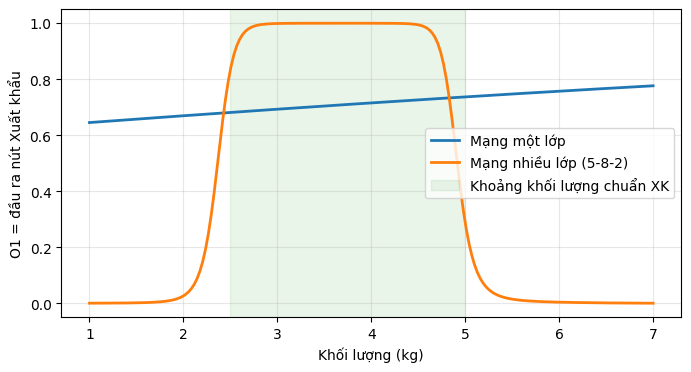

In [16]:
kl_range = np.linspace(1, 7, 200)
base = train_df[FEATURES].mean()
grid = pd.DataFrame([base] * len(kl_range))
grid['khoi_luong'] = kl_range
Xg = (grid[FEATURES] / X_max).values
Og1 = forward_1layer(Xg, W1, b1)[1]
Og2 = mlp.forward(Xg)
plt.figure(figsize=(8, 4))
plt.plot(kl_range, Og1[:, 0], label='Mạng một lớp', lw=2)
plt.plot(kl_range, Og2[:, 0], label='Mạng nhiều lớp (5-8-2)', lw=2)
plt.axvspan(2.5, 5.0, color='tab:green', alpha=0.1, label='Khoảng khối lượng chuẩn XK')
plt.xlabel('Khối lượng (kg)')
plt.ylabel('O1 = đầu ra nút Xuất khẩu')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Trả lời Câu hỏi 7
- **Mạng một lớp:** đường gần như thẳng, tăng nhẹ từ ≈ 0.65 (1 kg) lên ≈ 0.78 (7 kg). Vì $O_1 = \text{sigmoid}(\mathbf{w}\cdot\mathbf{x} - b)$ đơn điệu theo từng đầu vào, khi chỉ khối lượng thay đổi thì $O_1$ chỉ có thể luôn tăng (ở đây $w_{khoi\_luong} > 0$ nhỏ) – không phân biệt được trái quá nhỏ hay quá to.
- **Mạng nhiều lớp:** đường có dạng **"bậc thềm"**: gần 0 khi dưới 2 kg, tăng vọt quanh 2.3 – 2.5 kg, gần 1 trong khoảng 2.5 – 4.7 kg và giảm về gần 0 sau 5 kg – khớp với khoảng tô màu.
- **Vì sao lớp ẩn giúp biểu diễn quan hệ "tăng rồi giảm"?** Mỗi nút ẩn tạo ra một đường sigmoid theo khối lượng với vị trí (do bias) và chiều (do dấu trọng số) khác nhau; nút ra lấy **tổ hợp có trọng số** của chúng. Hiệu của hai sigmoid lệch nhau (một bật lên quanh 2.5 kg, một bật lên quanh 5 kg) tạo thành "bậc thềm" – đúng dạng hàm `band` dùng để sinh dữ liệu. Đây là minh họa trực quan cho **tính chất xấp xỉ vạn năng** của mạng có lớp ẩn.

## Bước 10. So sánh với scikit-learn MLPClassifier

In [17]:
from sklearn.neural_network import MLPClassifier
sk = MLPClassifier(hidden_layer_sizes=(8,), activation='logistic', solver='adam',
                   learning_rate_init=0.05, max_iter=5000, random_state=1)
sk.fit(X_train, y_train)
print(f'sklearn MLPClassifier (5-8-1) - độ chính xác test: {sk.score(X_test, y_test):.3f}')

sklearn MLPClassifier (5-8-1) - độ chính xác test: 0.950


**Nhận xét:** sklearn đạt 0.950, chênh với bản tự cài đặt (0.938) chỉ 1 trái trên 80 trái test (1.25 điểm %), nằm trong mức dao động bình thường; một phần do sklearn học trên cả 320 mẫu train (bản tự cài đặt học trên 256 mẫu), dùng một nút ra và thuật toán Adam.

## Bước 11. Phân loại lô sầu riêng mới

In [18]:
new_fruits = pd.DataFrame({
    'khoi_luong':        [3.8, 6.2, 1.5, 4.2],
    'do_brix':           [33.0, 34.0, 31.0, 26.0],
    'ty_le_com':         [30.0, 31.0, 29.0, 22.0],
    'do_day_vo':         [8.0, 8.5, 7.5, 11.5],
    'so_ngay_thu_hoach': [2, 2, 3, 8]},
    index=['Trai_A', 'Trai_B', 'Trai_C', 'Trai_D'])
Xn = (new_fruits[FEATURES] / X_max).values
On1 = forward_1layer(Xn, W1, b1)[1]
On2 = mlp.forward(Xn)
new_fruits['O1 (một lớp)'] = On1[:, 0].round(3)
new_fruits['O1 (nhiều lớp)'] = On2[:, 0].round(3)
new_fruits['Kết luận (nhiều lớp)'] = np.where(np.argmax(On2, 1) == 0, 'Xuất khẩu', 'Nội địa')
new_fruits

,khoi_luong,do_brix,ty_le_com,do_day_vo,so_ngay_thu_hoach,O1 (một lớp),O1 (nhiều lớp),Kết luận (nhiều lớp)
Trai_A,3.8,33.0,30.0,8.0,2,0.949,1.000,Xuất khẩu
Trai_B,6.2,34.0,31.0,8.5,2,0.975,0.013,Nội địa
Trai_C,1.5,31.0,29.0,7.5,3,0.855,0.021,Nội địa
Trai_D,4.2,26.0,22.0,11.5,8,0.125,0.000,Nội địa


### Trả lời Câu hỏi 8
- **Mạng một lớp** cho B và C xác suất xuất khẩu rất cao (≈ 0.975 và 0.855) vì hai trái có Brix, tỷ lệ cơm cao và vỏ mỏng; nó gần như bỏ qua khối lượng ⇒ kết luận **Xuất khẩu** cho cả hai.
- **Mạng nhiều lớp** cho cả hai dưới 0.03 ⇒ **Nội địa**, vì khối lượng 6.2 kg và 1.5 kg nằm ngoài khoảng 2.5 – 5 kg.
- **Mạng nhiều lớp hợp lý hơn** với tiêu chí thu mua (trái quá to khó đóng thùng theo quy cách, trái quá nhỏ ít cơm), vì nó đã học được quan hệ khoảng "2.5 – 5 kg". Trái A (đạt mọi tiêu chí) được cả hai mạng xếp Xuất khẩu, trái D (Brix thấp, vỏ dày, để lâu) cả hai xếp Nội địa.
- **Bài học:** độ chính xác tổng thể chưa đủ; cần kiểm tra mô hình trên các **trường hợp biên** có ý nghĩa nghiệp vụ.

---
# 7. BÀI TẬP VỀ NHÀ

### Bài 1. Thay số nút ẩn H ∈ {2; 4; 16; 32}
Chọn H tốt nhất theo cross-entropy **kiểm định** nhỏ nhất (H = 8 ở Bước 8 được đưa vào để so sánh); chỉ sau khi đã chọn mới báo cáo độ chính xác test của H đó.

In [19]:
res_H = {}
models_H = {}
for H in [2, 4, 8, 16, 32]:
    m = MLP(n_in=5, n_hidden=H, n_out=2, seed=1).fit(X_sub, T_sub, X_val, T_val, eta=0.5, epochs=3000, batch=16)
    hh = np.array(m.hist)
    models_H[H] = m
    res_H[H] = {'CE kiểm định nhỏ nhất': hh[:, 1].min(), 'epoch tốt nhất': m.best_epoch,
                'acc kiểm định': accuracy_score(T_val[:, 0], m.predict(X_val))}
    print(f'H = {H:2d}: CE kiểm định nhỏ nhất = {hh[:, 1].min():.4f} tại epoch {m.best_epoch}')
res_H = pd.DataFrame(res_H).T
display(res_H)
H_best = res_H['CE kiểm định nhỏ nhất'].astype(float).idxmin()
print(f'=> Chọn H = {H_best} (CE kiểm định nhỏ nhất).')
print(f'Độ chính xác TEST của H = {H_best}: {accuracy_score(y_test, models_H[H_best].predict(X_test)):.3f}')

H =  2: CE kiểm định nhỏ nhất = 0.4337 tại epoch 2919
H =  4: CE kiểm định nhỏ nhất = 0.5142 tại epoch 684
H =  8: CE kiểm định nhỏ nhất = 0.5368 tại epoch 663
H = 16: CE kiểm định nhỏ nhất = 0.5572 tại epoch 294
H = 32: CE kiểm định nhỏ nhất = 0.6206 tại epoch 236


,CE kiểm định nhỏ nhất,epoch tốt nhất,acc kiểm định
2,0.4337,2919.0,0.9531
4,0.5142,684.0,0.9531
8,0.5368,663.0,0.9375
16,0.5572,294.0,0.9062
32,0.6206,236.0,0.8594


=> Chọn H = 2 (CE kiểm định nhỏ nhất).
Độ chính xác TEST của H = 2: 0.912


**Nhận xét Bài 1:** - **Kết quả theo tập kiểm định:** H = 2 có CE kiểm định nhỏ nhất (0.434), tiếp theo H = 4 (0.514), H = 8 (0.537), H = 16 (0.557), H = 32 (0.621) ⇒ **chọn H = 2**, độ chính xác test của H = 2 là **0.912**.
- **Xu hướng:** H càng lớn thì mạng càng nhiều tham số, khớp tập học nhanh hơn và **quá khớp sớm hơn** (epoch tốt nhất giảm từ 2919 với H = 2 xuống 236 với H = 32), CE kiểm định nhỏ nhất cũng tệ hơn. Với H = 2, mạng học chậm (epoch tốt nhất gần cuối 3000 epoch, có thể còn giảm tiếp nếu chạy lâu hơn) nhưng ít quá khớp. Điều này hợp lý vì quy luật cần học chỉ là "bậc thềm" theo khối lượng – về lý thuyết chỉ cần 2 nút ẩn (hai sigmoid lệch nhau) cộng phần tuyến tính của các thuộc tính khác.
- **Lưu ý trung thực:** độ chính xác test của H = 2 (0.912) thấp hơn H = 8 (0.938) – chênh 2 trái trên 80. Ta **không được** đổi lựa chọn sau khi nhìn tập test; tập kiểm định chỉ có 64 mẫu nên tiêu chí chọn còn nhiễu. Nếu muốn chọn H chắc chắn hơn, nên dùng kiểm định chéo (k-fold) trên tập train.

### Bài 2. Ảnh hưởng của hệ số học η
**(a) Mạng một lớp** với η ∈ {0.02; 0.05; 0.2}

η = 0.02: CE cuối = 1.009 | CE nhỏ nhất = 1.009 | độ dao động CE (std 100 epoch cuối) = 0.0068 | acc test = 0.762
η = 0.05: CE cuối = 0.992 | CE nhỏ nhất = 0.990 | độ dao động CE (std 100 epoch cuối) = 0.0128 | acc test = 0.762
η = 0.2 : CE cuối = 0.990 | CE nhỏ nhất = 0.989 | độ dao động CE (std 100 epoch cuối) = 0.0646 | acc test = 0.762


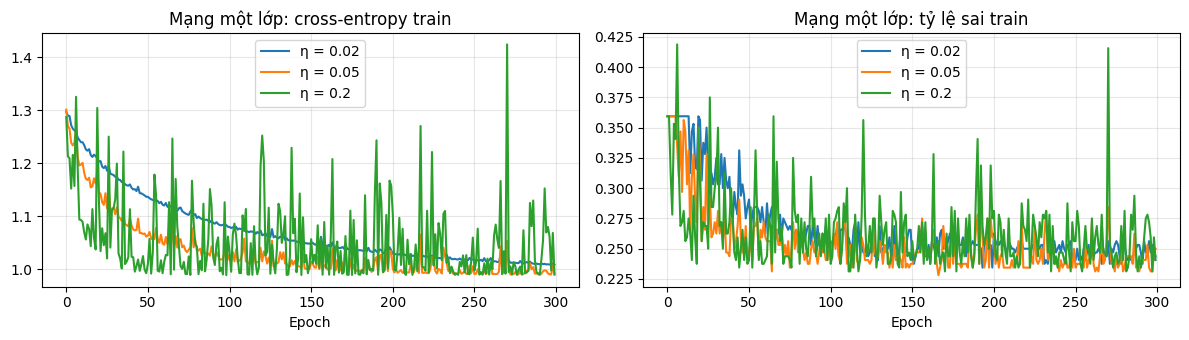

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for e in [0.02, 0.05, 0.2]:
    We, be, he = train_1layer(X_train, T_train, W, b, eta=e, epochs=300)
    acc_e = accuracy_score(y_test, (np.argmax(forward_1layer(X_test, We, be)[1], 1) == 0).astype(int))
    print(f'η = {e:<4}: CE cuối = {he[-1, 0]:.3f} | CE nhỏ nhất = {he[:, 0].min():.3f} | '
          f'độ dao động CE (std 100 epoch cuối) = {he[-100:, 0].std():.4f} | acc test = {acc_e:.3f}')
    ax[0].plot(he[:, 0], label=f'η = {e}')
    ax[1].plot(he[:, 1], label=f'η = {e}')
ax[0].set_title('Mạng một lớp: cross-entropy train')
ax[1].set_title('Mạng một lớp: tỷ lệ sai train')
for a in ax:
    a.set_xlabel('Epoch')
    a.legend()
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**(b) Mạng nhiều lớp 5-8-2** với η ∈ {0.05; 0.5; 2.0}

η = 0.05: CE kiểm định nhỏ nhất = 0.5612 tại epoch 2625 | CE kiểm định cuối = 0.570 | CE học cuối = 0.179
η = 0.5 : CE kiểm định nhỏ nhất = 0.5368 tại epoch  663 | CE kiểm định cuối = 0.945 | CE học cuối = 0.044
η = 2.0 : CE kiểm định nhỏ nhất = 0.4445 tại epoch  455 | CE kiểm định cuối = 1.614 | CE học cuối = 0.008


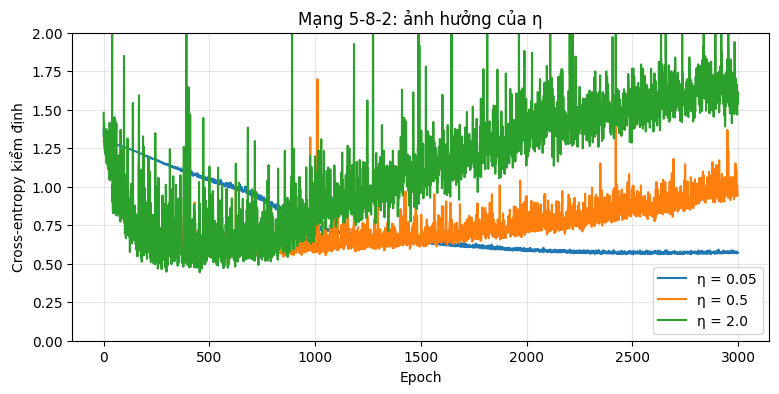

In [21]:
plt.figure(figsize=(9, 4))
for e in [0.05, 0.5, 2.0]:
    m = MLP(n_in=5, n_hidden=8, n_out=2, seed=1).fit(X_sub, T_sub, X_val, T_val, eta=e, epochs=3000, batch=16)
    hh = np.array(m.hist)
    print(f'η = {e:<4}: CE kiểm định nhỏ nhất = {hh[:, 1].min():.4f} tại epoch {m.best_epoch:4d} | '
          f'CE kiểm định cuối = {hh[-1, 1]:.3f} | CE học cuối = {hh[-1, 0]:.3f}')
    plt.plot(hh[:, 1], label=f'η = {e}')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy kiểm định')
plt.title('Mạng 5-8-2: ảnh hưởng của η')
plt.ylim(0, 2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Nhận xét Bài 2:** **(a) Mạng một lớp:** η càng nhỏ thì đường cross-entropy càng **mượt** (độ lệch chuẩn của CE trong 100 epoch cuối: 0.0068 với η = 0.02, 0.0128 với η = 0.05, 0.0646 với η = 0.2), vì mỗi mẫu chỉ kéo trọng số đi một đoạn nhỏ. Tuy nhiên CE đều dừng quanh **0.99 – 1.01** và độ chính xác test đều là **0.762**: mô hình một lớp đã chạm giới hạn biểu diễn, η chỉ ảnh hưởng tới độ dao động chứ không cải thiện kết quả. η nhỏ (0.02) hội tụ chậm hơn một chút (CE cuối 1.009 > 0.990).

**(b) Mạng 5-8-2:**
- η = 0.05: hội tụ **chậm**, CE kiểm định nhỏ nhất (0.561) chỉ đạt ở epoch 2625; trong 3000 epoch gần như chưa quá khớp (CE kiểm định cuối 0.570, CE học cuối 0.179).
- η = 0.5: cân bằng – tốt nhất ở epoch 663 (0.537), sau đó quá khớp (CE kiểm định cuối 0.945).
- η = 2.0: hội tụ **nhanh nhất**, đạt CE kiểm định thấp nhất (0.445) ở epoch 455, nhưng sau đó quá khớp **mạnh nhất** (CE học về 0.008, CE kiểm định cuối 1.61).
- Kết luận: η lớn → học nhanh nhưng dễ dao động và quá khớp nhanh, bắt buộc phải có dừng sớm; η nhỏ → ổn định nhưng tốn nhiều epoch. Với dừng sớm theo tập kiểm định, η từ 0.5 đến 2.0 đều dùng được.

### Bài 3. Thay sigmoid ở lớp ẩn bằng tanh (đạo hàm $1 - h^2$)
Lớp ra vẫn dùng sigmoid + cross-entropy, nên $\delta^{(2)} = T - O$ giữ nguyên; chỉ đổi $\delta^{(1)} = (\delta^{(2)} W^{(2)T}) \odot (1 - h^2)$.

sigmoid, η=0.5 : CE kiểm định nhỏ nhất = 0.5368 tại epoch  663 | epoch đầu tiên CE kiểm định ≤ 0.7: 130 | acc test = 0.938
tanh, η=0.5    : CE kiểm định nhỏ nhất = 0.5165 tại epoch  159 | epoch đầu tiên CE kiểm định ≤ 0.7: 62 | acc test = 0.975
tanh, η=0.1    : CE kiểm định nhỏ nhất = 0.5583 tại epoch  294 | epoch đầu tiên CE kiểm định ≤ 0.7: 125 | acc test = 0.963


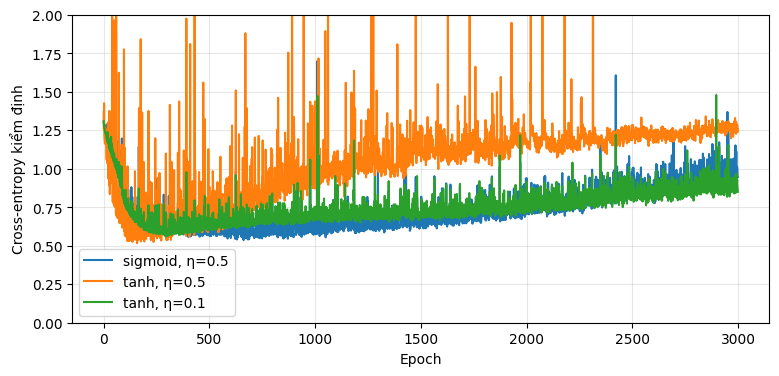

In [22]:
class MLP_tanh(MLP):
    def forward(self, X):
        self.h = np.tanh(X @ self.W1 - self.b1)
        self.O = sigmoid(self.h @ self.W2 - self.b2)
        return self.O
    def backward(self, X, T, eta):
        n = len(X)
        d2 = T - self.O
        d1 = (d2 @ self.W2.T) * (1 - self.h ** 2)
        self.W2 += eta * self.h.T @ d2 / n
        self.b2 += eta * (-1) * d2.mean(axis=0)
        self.W1 += eta * X.T @ d1 / n
        self.b1 += eta * (-1) * d1.mean(axis=0)

def epoch_reach(hist_va, level):
    idx = np.where(np.array(hist_va) <= level)[0]
    return int(idx[0]) + 1 if len(idx) else None

plt.figure(figsize=(9, 4))
for name, cls, e in [('sigmoid, η=0.5', MLP, 0.5), ('tanh, η=0.5', MLP_tanh, 0.5), ('tanh, η=0.1', MLP_tanh, 0.1)]:
    m = cls(n_in=5, n_hidden=8, n_out=2, seed=1).fit(X_sub, T_sub, X_val, T_val, eta=e, epochs=3000, batch=16)
    hh = np.array(m.hist)
    acc_t = accuracy_score(y_test, m.predict(X_test))
    print(f'{name:15s}: CE kiểm định nhỏ nhất = {hh[:, 1].min():.4f} tại epoch {m.best_epoch:4d} | '
          f'epoch đầu tiên CE kiểm định ≤ 0.7: {epoch_reach(hh[:, 1], 0.7)} | acc test = {acc_t:.3f}')
    plt.plot(hh[:, 1], label=name)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy kiểm định')
plt.ylim(0, 2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Nhận xét Bài 3:** - Với cùng η = 0.5, mạng dùng **tanh hội tụ nhanh hơn rõ rệt**: CE kiểm định xuống dưới 0.7 ở epoch **62** (sigmoid: 130), đạt mức nhỏ nhất ở epoch **159** (sigmoid: 663) với giá trị tốt hơn một chút (0.517 so với 0.537). Lần chạy này độ chính xác test của tanh là 0.975 (sigmoid 0.938), nhưng chênh lệch chỉ 3 trái/80 nên không nên kết luận quá mạnh từ một lần chạy.
- **Giải thích:** (1) đạo hàm của tanh là $1 - h^2$ có giá trị lớn nhất bằng 1, còn của sigmoid là $h(1-h) \le 0.25$ ⇒ tín hiệu sai số truyền ngược về lớp ẩn mạnh hơn khoảng 4 lần, trọng số W1 được cập nhật nhanh hơn; (2) đầu ra tanh nằm trong (−1, 1) và đối xứng quanh 0 nên đầu vào của lớp ra "cân bằng" hơn, gradient của W2 không bị lệch cùng một dấu.
- Kiểm chứng: tanh với η = 0.1 (nhỏ hơn 5 lần) cho tốc độ gần giống sigmoid với η = 0.5 (125 so với 130 epoch để CE ≤ 0.7), phù hợp với lập luận "đạo hàm lớn hơn khoảng 4 lần". Mặt trái: tanh học nhanh nên cũng **quá khớp sớm hơn**, càng cần dừng sớm.

### Bài 4. Thêm đặc trưng $(khoi\_luong - 3.75)^2$ cho mạng một lớp

In [23]:
def add_sq(d):
    d = d[FEATURES].copy()
    d['kl_lech_tam_2'] = (d['khoi_luong'] - 3.75) ** 2
    return d
F6 = FEATURES + ['kl_lech_tam_2']
tr6, te6 = add_sq(train_df), add_sq(test_df)
X6_max = tr6.max()
X6_train = (tr6 / X6_max).values
X6_test = (te6 / X6_max).values
W6_init = np.random.default_rng(7).uniform(0, 1, size=(6, 2)).round(2)
b6_init = np.random.default_rng(8).uniform(0, 1, size=2).round(2)
W6, b6, h6 = train_1layer(X6_train, T_train, W6_init, b6_init, eta=0.2, epochs=300)
pred6 = (np.argmax(forward_1layer(X6_test, W6, b6)[1], 1) == 0).astype(int)
acc6 = accuracy_score(y_test, pred6)
print(pd.DataFrame(W6, index=F6, columns=['Y1 (XK)', 'Y2 (ND)']).round(3))
print(f'CE train cuối: 5 đặc trưng = {hist1[-1, 0]:.3f} | 6 đặc trưng = {h6[-1, 0]:.3f}')
print(f'Độ chính xác test: một lớp 5 đặc trưng = {acc1:.3f} | một lớp + (kl-3.75)² = {acc6:.3f} | 5-8-2 = {acc2:.3f}')
print(classification_report(y_test, pred6, target_names=['Nội địa', 'Xuất khẩu']))

                   Y1 (XK)  Y2 (ND)
khoi_luong          -0.688    0.688
do_brix             29.582  -29.539
ty_le_com           17.748  -17.722
do_day_vo           -7.185    7.177
so_ngay_thu_hoach   -1.857    1.855
kl_lech_tam_2      -17.301   17.280
CE train cuối: 5 đặc trưng = 0.990 | 6 đặc trưng = 0.452
Độ chính xác test: một lớp 5 đặc trưng = 0.762 | một lớp + (kl-3.75)² = 0.938 | 5-8-2 = 0.938
              precision    recall  f1-score   support

     Nội địa       0.93      0.90      0.91        29
   Xuất khẩu       0.94      0.96      0.95        51

    accuracy                           0.94        80
   macro avg       0.94      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



**Nhận xét Bài 4:** - Thêm đặc trưng $(khoi\_luong - 3.75)^2$, độ chính xác test của **mạng một lớp tăng từ 0.762 lên 0.938** – bằng mạng nhiều lớp 5-8-2; recall lớp Nội địa tăng từ 0.62 lên 0.90; cross-entropy train giảm từ 0.99 xuống 0.45.
- Trọng số của đặc trưng mới nối vào Y₁ là **−17.3 (âm, rất lớn)**: trái càng lệch xa tâm 3.75 kg (quá nhỏ hoặc quá to) thì càng ít khả năng xuất khẩu – đúng tiêu chí "2.5 – 5 kg".
- **Giải thích:** quan hệ giữa nhãn và khối lượng là "tăng rồi giảm" (không đơn điệu), nhưng quan hệ giữa nhãn và $(khoi\_luong - 3.75)^2$ (độ lệch khỏi tâm) lại **đơn điệu giảm**. Mạng một lớp vẫn là mô hình tuyến tính, nhưng tuyến tính trong **không gian đặc trưng mở rộng**; trong không gian khối lượng ban đầu, ranh giới quyết định trở thành đường bậc hai (một khoảng quanh 3.75 kg). Đây là **kỹ thuật tạo đặc trưng (feature engineering)**: con người làm thủ công điều mà lớp ẩn tự học được. Hạn chế: cần biết trước dạng quan hệ (tâm 3.75 kg); mạng nhiều lớp thì tự tìm ra từ dữ liệu.

### Bài 5. Mạng một lớp 2 đầu ra cho bảng dữ liệu Á/Âu (slide 38 – 40)
> ⚠️ Bảng dữ liệu Á/Âu nằm trong **slide bài giảng** (không có trong các file được cung cấp). Hãy chép 8 bộ train, 4 bộ test và trọng số khởi tạo từ slide 38 – 40 vào các mảng có đánh dấu `TODO` bên dưới (các số hiện tại chỉ là **ví dụ giữ chỗ** để ô lệnh chạy được), rồi chạy lại ô.

In [24]:
# ===================== TODO: thay bằng số liệu trên slide 38 - 40 =====================
X_au_train = np.array([      # 8 bộ train, mỗi dòng là các đầu vào x1, x2, ... (đã chuẩn hóa như slide)
    [0.1, 0.9], [0.2, 0.8], [0.3, 0.7], [0.2, 0.6],
    [0.8, 0.2], [0.9, 0.1], [0.7, 0.3], [0.6, 0.4]])
T_au_train = np.array([      # đích one-hot: Á = (1, 0), Âu = (0, 1)
    [1, 0], [1, 0], [1, 0], [1, 0],
    [0, 1], [0, 1], [0, 1], [0, 1]])
X_au_test = np.array([[0.25, 0.75], [0.15, 0.65], [0.85, 0.25], [0.65, 0.35]])   # 4 bộ test
T_au_test = np.array([[1, 0], [1, 0], [0, 1], [0, 1]])
W_au = np.full((X_au_train.shape[1], 2), 0.5)   # trọng số khởi tạo như slide (kích thước: số đầu vào x 2)
b_au = np.array([0.5, 0.5])                     # bias khởi tạo như slide
# =======================================================================================
eta_au = 0.2

def epoch_online(X, T, W, b, eta):
    # Một epoch cập nhật trực tuyến theo đúng thứ tự dòng như khi tính tay trên slide
    W, b = W.copy(), b.copy()
    for i in range(len(X)):
        o = forward_1layer(X[i:i+1], W, b)[1][0]
        W += eta * np.outer(X[i], T[i] - o)
        b += eta * (-1) * (T[i] - o)
    return W, b

def report(X, T, W, b, name):
    O = forward_1layer(X, W, b)[1]
    V = np.argmax(O, 1)
    tab = pd.DataFrame({'Net(Á)': O[:, 0].round(4), 'Net(Âu)': O[:, 1].round(4),
                        'V': np.where(V == 0, 'Á', 'Âu'), 'T': np.where(T[:, 0] == 1, 'Á', 'Âu')})
    print(f'{name}: tỷ lệ đúng = {np.mean(V == np.argmax(T, 1)):.0%}')
    display(tab)

report(X_au_test, T_au_test, W_au, b_au, 'Test, trước khi học')
W_a, b_a = epoch_online(X_au_train, T_au_train, W_au, b_au, eta_au)
print('W sau 1 epoch:\n', W_a.round(4), '\nb =', b_a.round(4))
report(X_au_test, T_au_test, W_a, b_a, 'Test, sau 1 epoch')
W_c, b_c, h_au = train_1layer(X_au_train, T_au_train, W_au, b_au, eta=eta_au, epochs=300)
report(X_au_train, T_au_train, W_c, b_c, 'Train, sau 300 epoch')
report(X_au_test, T_au_test, W_c, b_c, 'Test, sau 300 epoch')

Test, trước khi học: tỷ lệ đúng = 50%


,Net(Á),Net(Âu),V,T
0,0.5000,0.5000,Á,Á
1,0.4750,0.4750,Á,Á
2,0.5125,0.5125,Á,Âu
3,0.5000,0.5000,Á,Âu


W sau 1 epoch:
 [[0.2382 0.7621]
 [0.6657 0.3395]] 
b = [0.5793 0.4133]
Test, sau 1 epoch: tỷ lệ đúng = 50%


,Net(Á),Net(Âu),V,T
0,0.4949,0.5080,Âu,Á
1,0.4723,0.4804,Âu,Á
2,0.4476,0.5792,Âu,Âu
3,0.4523,0.5500,Âu,Âu


Train, sau 300 epoch: tỷ lệ đúng = 100%


,Net(Á),Net(Âu),V,T
0,0.9978,0.0024,Á,Á
1,0.9887,0.0122,Á,Á
2,0.9427,0.0608,Á,Á
3,0.9447,0.0489,Á,Á
4,0.0039,0.9961,Âu,Âu
5,0.0007,0.9992,Âu,Âu
6,0.0203,0.9797,Âu,Âu
7,0.0990,0.9024,Âu,Âu


Test, sau 300 epoch: tỷ lệ đúng = 100%


,Net(Á),Net(Âu),V,T
0,0.9743,0.0275,Á,Á
1,0.9752,0.0220,Á,Á
2,0.0038,0.9965,Âu,Âu
3,0.0455,0.9548,Âu,Âu


**Nhận xét Bài 5:** *(điền sau khi thay số liệu thật của slide)* – so sánh tỷ lệ đúng trên 4 bộ test trước và sau khi học với kết quả 42% sai ở slide 39; nhận xét về chiều thay đổi của các cột trọng số (giống Câu hỏi 3).

---
## Bảng tổng hợp kết quả
| Mô hình | Tập đo | Độ chính xác |
|---|---|---|
| Mô hình cơ sở (luôn đoán Xuất khẩu) | Test | 0.637 |
| Mạng một lớp, trọng số ngẫu nhiên, chưa huấn luyện (Bước 5) | Train | 0.359 |
| Mạng một lớp 5-2, sigmoid, 300 epoch (Bước 7) | Test | 0.762 |
| Mạng nhiều lớp 5-8-2, lan truyền ngược, dừng sớm (Bước 8) | Test | 0.938 |
| sklearn MLPClassifier, 8 nút ẩn, logistic (Bước 10) | Test | 0.950 |